# Lab 14 – Complex Computing Activity
## Face Emotion Recognition with Live Webcam Overlay

**Project Name:** Face Emotion Recognition with Live Webcam Overlay  
**Roll No.:** 23-AI-40  
**Dataset:** FER-2013 (7 emotion classes, ~35,000 grayscale 48×48 images)


In [ ]:
import numpy as np
import os
import time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from sklearn.metrics import classification_report, confusion_matrix, f1_score
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
OpenCV: 4.13.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load Dataset from Kaggle

In [ ]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)
print("\nDirectory structure:")
for p in sorted(DATA_ROOT.rglob("*"))[:30]:
    print(" ", p.relative_to(DATA_ROOT))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013

Directory structure:
  test
  test/angry
  test/angry/PrivateTest_10131363.jpg
  test/angry/PrivateTest_10304478.jpg
  test/angry/PrivateTest_1054527.jpg
  test/angry/PrivateTest_10590091.jpg
  test/angry/PrivateTest_1109992.jpg
  test/angry/PrivateTest_11296953.jpg
  test/angry/PrivateTest_12000629.jpg
  test/angry/PrivateTest_12008383.jpg
  test/angry/PrivateTest_12191716.jpg
  test/angry/PrivateTest_1221822.jpg
  test/angry/PrivateTest_12403575.jpg
  test/angry/PrivateTest_12766285.jpg
  test/angry/PrivateTest_12846357.jpg
  test/angry/PrivateTest_1290484.jpg
  test/angry/PrivateTest_12912780.jpg
  test/angry/PrivateTest_13164119.jpg
  test/angry/PrivateTest_13278552.jpg
  test/angry/PrivateTest_13463625.jpg
  test/angry/PrivateTest_13541561.jpg
  test/angry/PrivateTest_13664224.jpg
  test/angry/PrivateTest_14325168.jpg
  test/angry/PrivateTest_14426977.jpg
  test/angry/Privat

In [ ]:
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'
EMOTIONS  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(EMOTIONS)
print("Emotion classes:", EMOTIONS)
print("Num classes:", NUM_CLASSES)
train_counts = {e: len(list((TRAIN_DIR/e).glob('*.jpg'))) for e in EMOTIONS}
test_counts  = {e: len(list((TEST_DIR/e).glob('*.jpg')))  for e in EMOTIONS}
print("\nTrain samples per class:", train_counts)
print("Test samples per class: ", test_counts)

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Num classes: 7

Train samples per class: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test samples per class:  {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


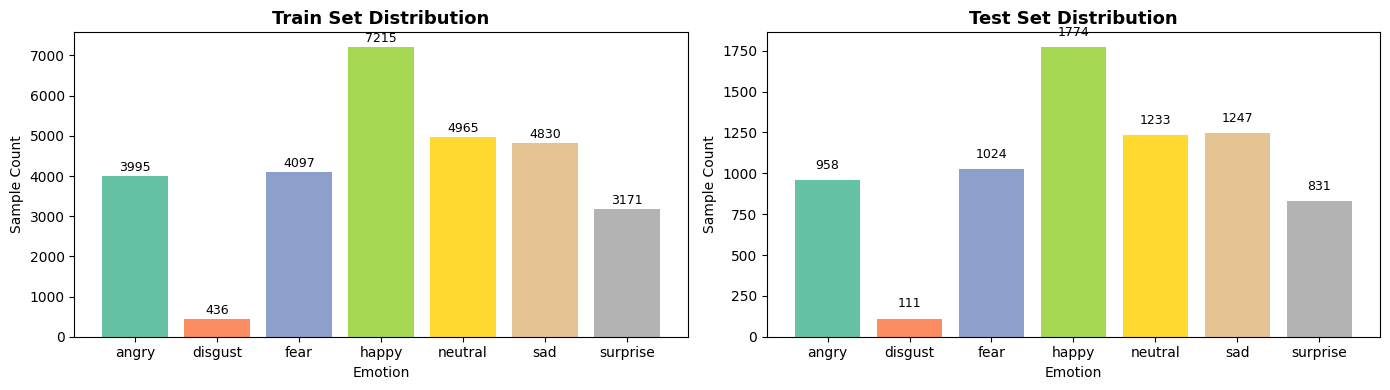

Total train samples: 28709
Total test  samples: 7178


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Train Set Distribution', 'Test Set Distribution']):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES)))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Sample Count')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Total train samples:", sum(train_counts.values()))
print("Total test  samples:", sum(test_counts.values()))

Image Preprocessing

In [ ]:
IMG_SIZE_GRAY = 48
IMG_SIZE_COLOR = 96
BATCH_SIZE = 64
EPOCHS_SCRATCH = 50
EPOCHS_FINETUNE = 20
def preprocess_face_gray(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(blurred)
    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    norm = resized.astype('float32') / 255.0
    return norm[..., np.newaxis]

def preprocess_face_color(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE_COLOR, IMG_SIZE_COLOR))
    return applications.mobilenet_v2.preprocess_input(resized.astype('float32'))
print("Preprocessing functions defined.")

Preprocessing functions defined.


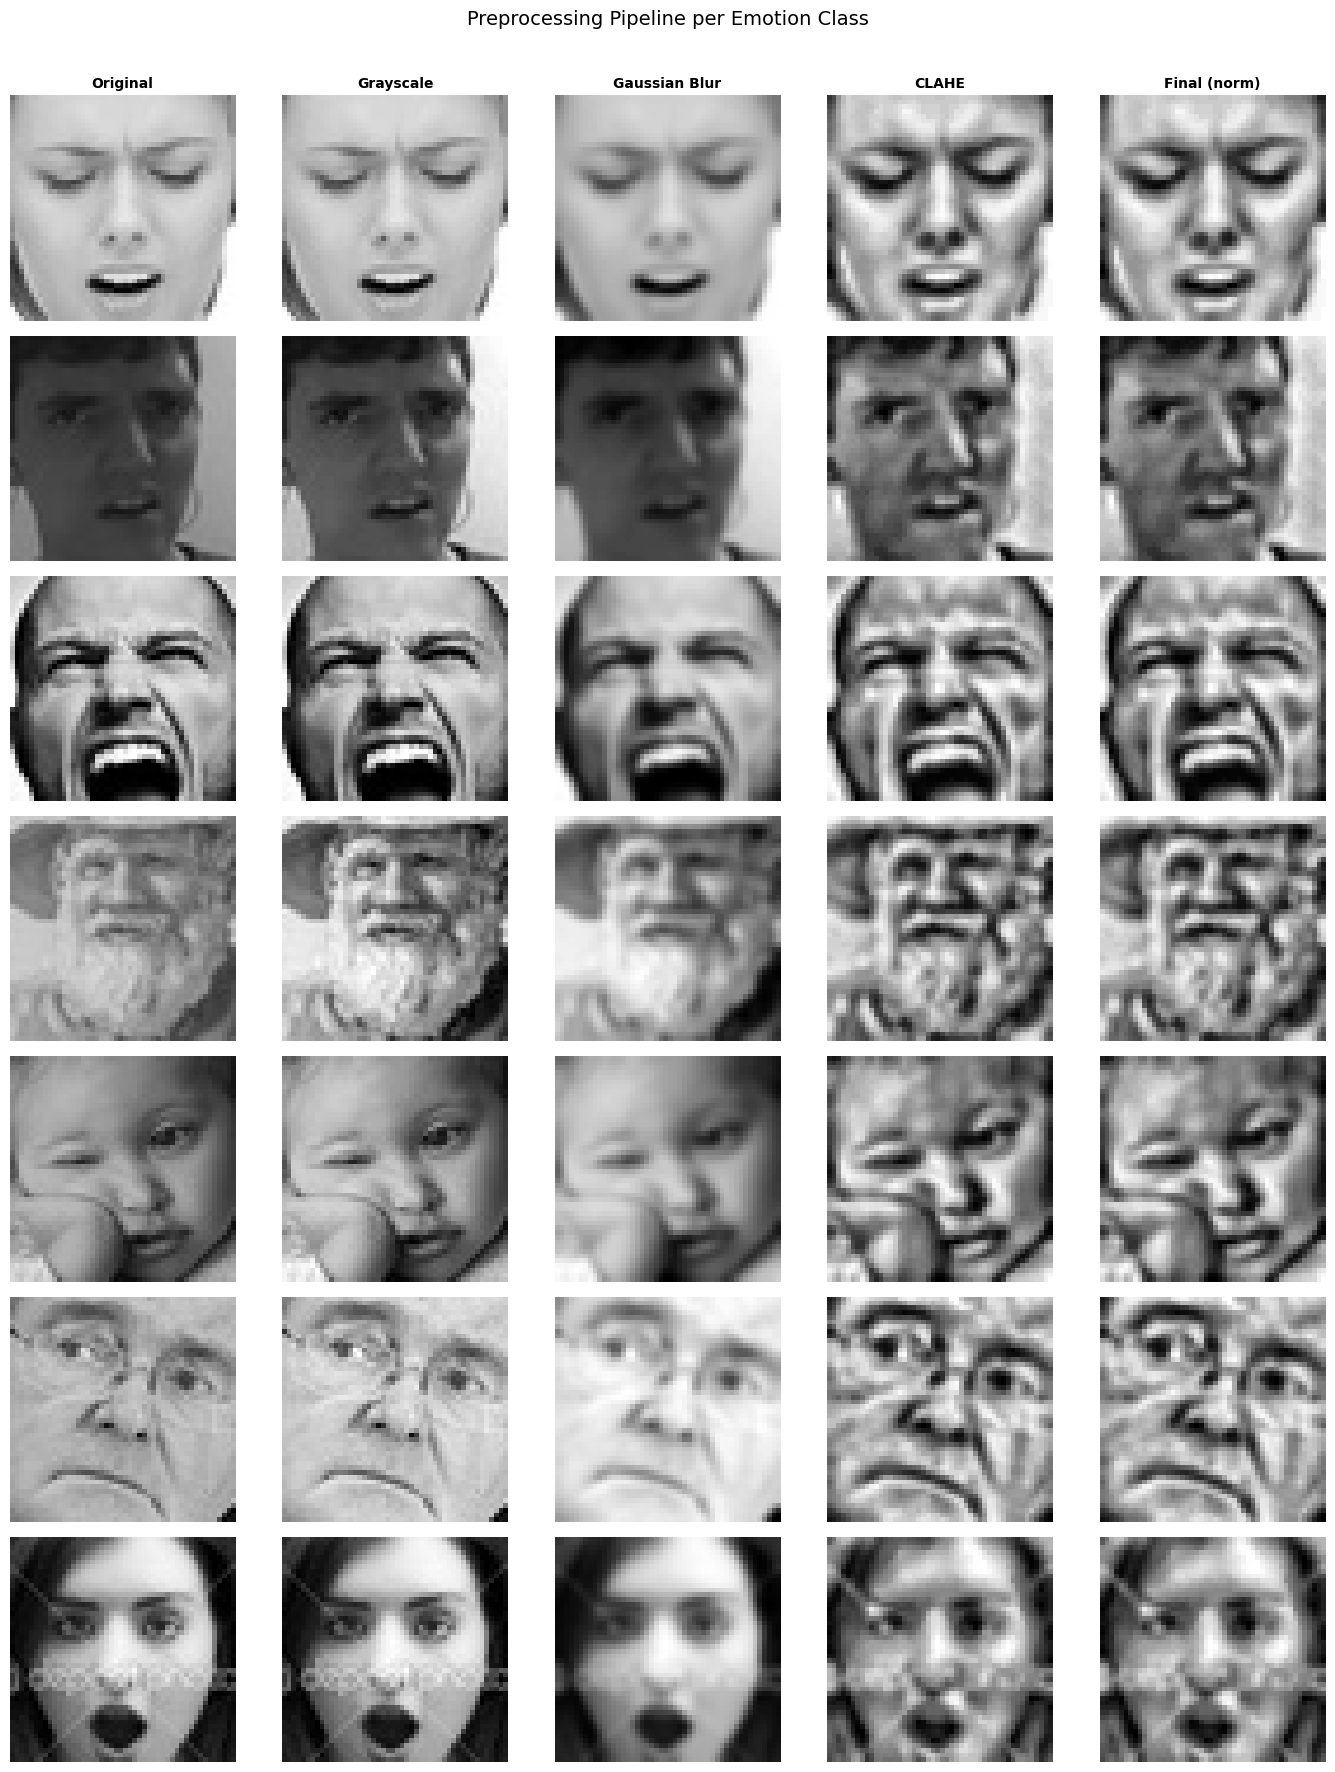

In [ ]:
fig, axes = plt.subplots(len(EMOTIONS), 5, figsize=(14, 2.5 * len(EMOTIONS)))
steps = ['Original', 'Grayscale', 'Gaussian Blur', 'CLAHE', 'Final (norm)']
for row, emotion in enumerate(EMOTIONS):
    img_path = list((TRAIN_DIR / emotion).glob('*.jpg'))[0]
    img_bgr = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(blurred)
    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    imgs = [cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), gray, blurred, eq, resized]
    cmaps = [None, 'gray', 'gray', 'gray', 'gray']
    for col, (im, cmap, step) in enumerate(zip(imgs, cmaps, steps)):
        axes[row, col].imshow(im, cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(step, fontsize=10, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(emotion, fontsize=9, rotation=90, labelpad=10)
plt.suptitle('Preprocessing Pipeline per Emotion Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def load_and_preprocess_gray(file_path, label):#For CNN and VGG
    raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE_GRAY, IMG_SIZE_GRAY])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def load_and_preprocess_color(file_path, label):#For mobilenet
    raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE_COLOR, IMG_SIZE_COLOR])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(img, tf.float32))
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    return img, label

def build_dataset(directory, preprocess_fn, augment_data=False, shuffle=True):
    file_paths, labels = [], []
    for idx, emotion in enumerate(EMOTIONS):
        imgs = list((directory / emotion).glob('*.jpg'))
        file_paths.extend([str(p) for p in imgs])
        labels.extend([idx] * len(imgs))
    ds = tf.data.Dataset.from_tensor_slices(
            (file_paths, tf.one_hot(labels, NUM_CLASSES)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=42)
    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds
train_ds_gray = build_dataset(TRAIN_DIR,load_and_preprocess_gray, augment_data=True)
val_ds_gray = build_dataset(TEST_DIR,load_and_preprocess_gray, augment_data=False, shuffle=False)
train_ds_color = build_dataset(TRAIN_DIR,load_and_preprocess_color, augment_data=True)
val_ds_color = build_dataset(TEST_DIR,load_and_preprocess_color, augment_data=False, shuffle=False)

print("Gray train batches :", len(train_ds_gray))
print("Gray val batches :", len(val_ds_gray))
print("Color train batches:", len(train_ds_color))

Gray train batches : 449
Gray val batches : 113
Color train batches: 449


In [ ]:
def build_scratch_cnn(input_shape=(48, 48, 1), num_classes=7):#CNN
    inp = layers.Input(shape=input_shape, name='input')
    #First Block with 32 filters
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    #Second Block with 64 filters
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    #Third Block with 128
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    #Third Block with 256
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out, name='scratch_cnn')
    return model
scratch_model = build_scratch_cnn()
scratch_model.summary()
print(f"\nTrainable params: {scratch_model.count_params():,}")

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,111 (4.74 MB)

 Trainable params: 1,241,191 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)


Trainable params: 1,243,111


In [ ]:
def build_pretrained_model(input_shape=(96, 96, 3), num_classes=7, trainable=False):
    base = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    if not trainable:
        base.trainable = False        # Freeze all backbone layers
    else:
        base.trainable = True
        # Unfreeze only the last 30 layers for fine-tuning
        for layer in base.layers[:-30]:
            layer.trainable = False
    inp = layers.Input(shape=input_shape, name='input_color')
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    name = 'mobilenetv2_frozen' if not trainable else 'mobilenetv2_finetuned'
    model = models.Model(inp, out, name=name)
    return model
pretrained_frozen_model = build_pretrained_model(trainable=False)
pretrained_frozen_model.summary()
print(f"\nTrainable params: {pretrained_frozen_model.count_params():,}")

Model: "mobilenetv2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_color (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,983 (11.62 MB)

 Trainable params: 788,999 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 3,046,983


In [ ]:
def vgg_double_conv_block(x, filters, dropout_rate=0.3, name=''):
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_vgg_style_model(input_shape=(48, 48, 1), num_classes=7):
    inp = layers.Input(shape=input_shape, name='input_vgg')
    x = vgg_double_conv_block(inp, 32, dropout_rate=0.25, name='block1')
    x = vgg_double_conv_block(x, 64,dropout_rate=0.25, name='block2')
    x = vgg_double_conv_block(x, 128, dropout_rate=0.30, name='block3')
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out, name='vgg_style')
    return model
vgg_model = build_vgg_style_model()
vgg_model.summary()
print(f"\nTrainable params: {vgg_model.count_params():,}")

Model: "vgg_style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_vgg (InputLayer)          │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 487,399 (1.86 MB)

 Trainable params: 486,503 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)


Trainable params: 487,399


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
def get_callbacks(model_name):
    return [
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',save_best_only=True, verbose=1),
        callbacks.EarlyStopping(
            monitor='val_accuracy',patience=5,restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2,verbose=1)
    ]

def compile_and_train(model, train_ds, val_ds, epochs, lr=1e-3, model_name='model'):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    train_labels_list = []
    for idx, emotion in enumerate(EMOTIONS):
        n = len(list((TRAIN_DIR / emotion).glob('*.jpg')))
        train_labels_list.extend([idx] * n)
    train_labels_arr = np.array(train_labels_list)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels_arr),
        y=train_labels_arr
    )
    class_weights = dict(enumerate(class_weights))
    t0 = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        class_weight=class_weights,
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n⏱  Training time: {elapsed/60:.1f} min")
    return history, elapsed

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2)
        ax.set_title(f'{title} — {metric.capitalize()}', fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_history.png',
                dpi=150, bbox_inches='tight')
    plt.show()
print("Utilities defined.")

Utilities defined.


TRAINING MODEL 1: CNN from Scratch
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.1692 - loss: 2.0332
Epoch 1: val_accuracy improved from None to 0.20201, saving model to best_scratch_cnn.keras

Epoch 1: finished saving model to best_scratch_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 76s 133ms/step - accuracy: 0.1791 - loss: 1.9444 - val_accuracy: 0.2020 - val_loss: 1.8937 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2389 - loss: 1.7841
Epoch 2: val_accuracy improved from 0.20201 to 0.24937, saving model to best_scratch_cnn.keras

Epoch 2: finished saving model to best_scratch_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.2808 - loss: 1.7436 - val_accuracy: 0.2494 - val_loss: 1.9097 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3786 - loss: 1.6008
Epoch 3: val_accuracy improved from 0.24937 to 0.43452, saving model to best_scratch_cnn.keras

Epoch 3: finished

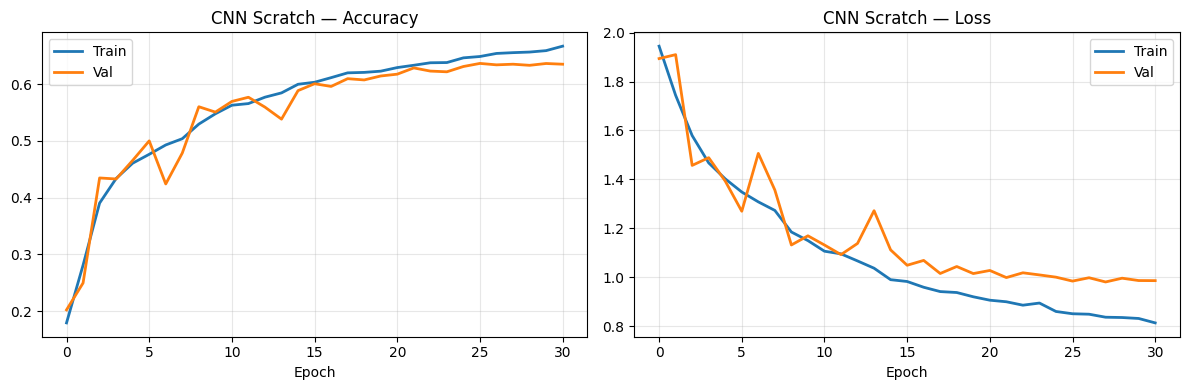

In [ ]:
print("=" * 60)
print("TRAINING MODEL 1: CNN from Scratch")
print("=" * 60)
scratch_model = build_scratch_cnn()
history_scratch, time_scratch = compile_and_train(
    scratch_model, train_ds_gray, val_ds_gray,
    epochs=EPOCHS_SCRATCH, lr=1e-3, model_name='scratch_cnn'
)
plot_history(history_scratch, 'CNN Scratch')

TRAINING MODEL 2a: MobileNetV2 Frozen Backbone
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2639 - loss: 1.8939
Epoch 1: val_accuracy improved from None to 0.39816, saving model to best_mobilenet_frozen.keras

Epoch 1: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 62s 97ms/step - accuracy: 0.2975 - loss: 1.7761 - val_accuracy: 0.3982 - val_loss: 1.5494 - learning_rate: 0.0010
Epoch 2/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3508 - loss: 1.6255
Epoch 2: val_accuracy improved from 0.39816 to 0.41474, saving model to best_mobilenet_frozen.keras

Epoch 2: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3563 - loss: 1.6298 - val_accuracy: 0.4147 - val_loss: 1.5456 - learning_rate: 0.0010
Epoch 3/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3822 - loss: 1.5634
Epoch 3: val_accuracy improved from 0.41474 to 0.42045, saving model to best_mobile

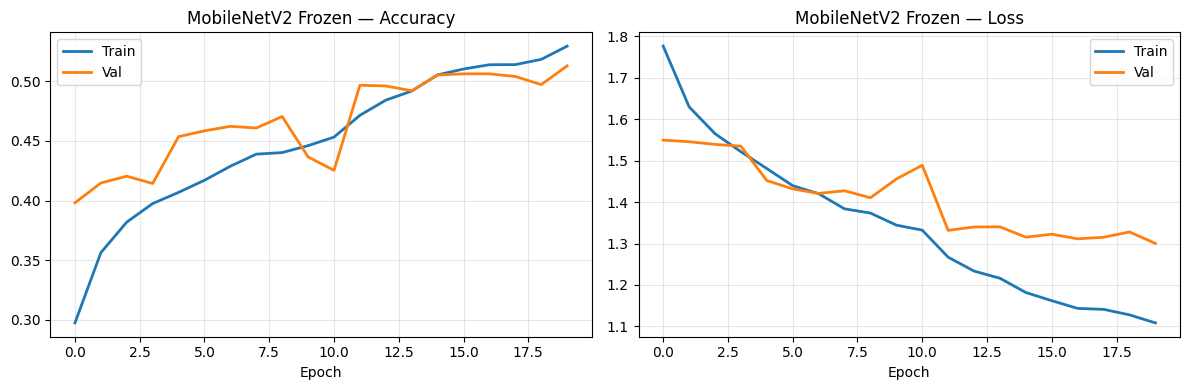

In [ ]:
print("=" * 60)
print("TRAINING MODEL 2a: MobileNetV2 Frozen Backbone")
print("=" * 60)
pretrained_frozen_model = build_pretrained_model(trainable=False)
history_frozen, time_frozen = compile_and_train(
    pretrained_frozen_model, train_ds_color, val_ds_color,
    epochs=20, lr=1e-3, model_name='mobilenet_frozen'
)
plot_history(history_frozen, 'MobileNetV2 Frozen')

TRAINING MODEL 2b: MobileNetV2 Fine-tuned
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1410 - loss: 2.2450
Epoch 1: val_accuracy improved from None to 0.25773, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 53s 78ms/step - accuracy: 0.1689 - loss: 2.1284 - val_accuracy: 0.2577 - val_loss: 1.9028 - learning_rate: 1.0000e-05
Epoch 2/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2295 - loss: 1.9146
Epoch 2: val_accuracy improved from 0.25773 to 0.33310, saving model to best_mobilenet_finetuned.keras

Epoch 2: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.2411 - loss: 1.8928 - val_accuracy: 0.3331 - val_loss: 1.7469 - learning_rate: 1.0000e-05
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2884 - loss: 1.7802
Epoch 3: val_accuracy improved from 0.33310 to 0.37517, saving model

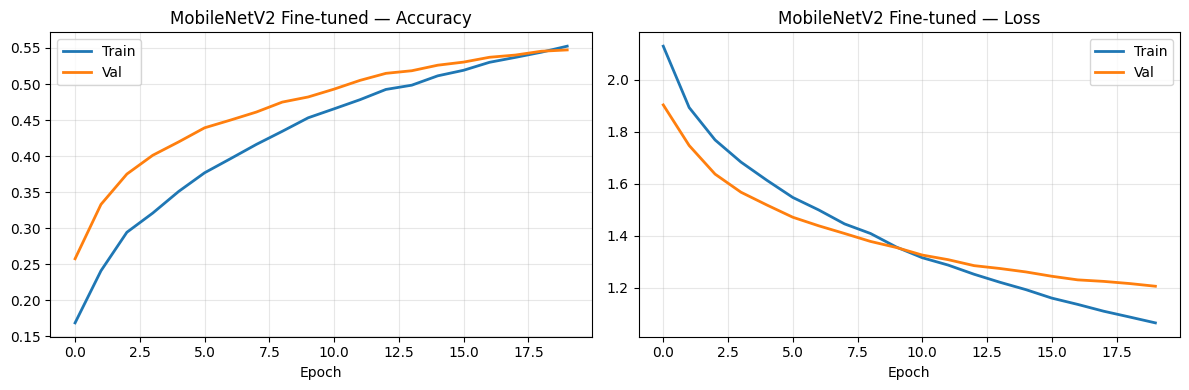

In [ ]:
print("=" * 60)
print("TRAINING MODEL 2b: MobileNetV2 Fine-tuned")
print("=" * 60)
finetuned_model = build_pretrained_model(trainable=True)
history_finetune, time_finetune = compile_and_train(
    finetuned_model, train_ds_color, val_ds_color,
    epochs=EPOCHS_FINETUNE, lr=1e-5,
    model_name='mobilenet_finetuned'
)
plot_history(history_finetune, 'MobileNetV2 Fine-tuned')

TRAINING MODEL 3: VGG-Style Double Conv Block
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1558 - loss: 2.0104
Epoch 1: val_accuracy improved from None to 0.02633, saving model to best_vgg_style.keras

Epoch 1: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.1668 - loss: 1.9432 - val_accuracy: 0.0263 - val_loss: 2.0441 - learning_rate: 0.0010
Epoch 2/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1895 - loss: 1.8728
Epoch 2: val_accuracy improved from 0.02633 to 0.30482, saving model to best_vgg_style.keras

Epoch 2: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.2068 - loss: 1.8367 - val_accuracy: 0.3048 - val_loss: 1.7837 - learning_rate: 0.0010
Epoch 3/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2588 - loss: 1.7374
Epoch 3: val_accuracy improved from 0.30482 to 0.32530, saving model to best_vgg_style.keras

Epoch 3: finished 

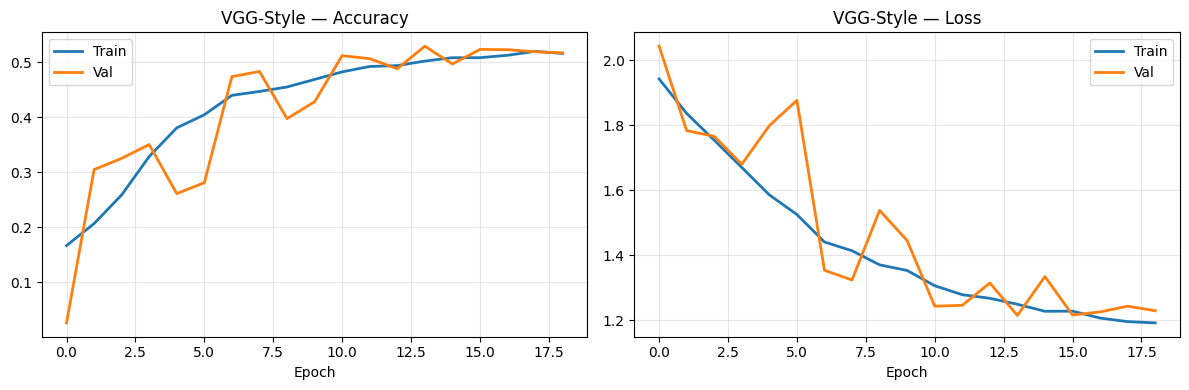

In [ ]:
print("=" * 60)
print("TRAINING MODEL 3: VGG-Style Double Conv Block")
print("=" * 60)
vgg_model = build_vgg_style_model()
history_vgg, time_vgg = compile_and_train(
    vgg_model, train_ds_gray, val_ds_gray,
    epochs=EPOCHS_SCRATCH, lr=1e-3, model_name='vgg_style'
)
plot_history(history_vgg, 'VGG-Style')

In [ ]:
best_scratch = tf.keras.models.load_model('best_scratch_cnn.keras')
best_frozen = tf.keras.models.load_model('best_mobilenet_frozen.keras')
best_finetune = tf.keras.models.load_model('best_mobilenet_finetuned.keras')
best_vgg = tf.keras.models.load_model('best_vgg_style.keras')
print("All best models loaded.")

All best models loaded.



Model: CNN Scratch
              precision    recall  f1-score   support

       angry       0.55      0.59      0.57       958
     disgust       0.52      0.74      0.61       111
        fear       0.53      0.32      0.40      1024
       happy       0.87      0.83      0.85      1774
     neutral       0.58      0.63      0.60      1233
         sad       0.47      0.54      0.50      1247
    surprise       0.74      0.82      0.77       831

    accuracy                           0.64      7178
   macro avg       0.61      0.64      0.61      7178
weighted avg       0.64      0.64      0.63      7178



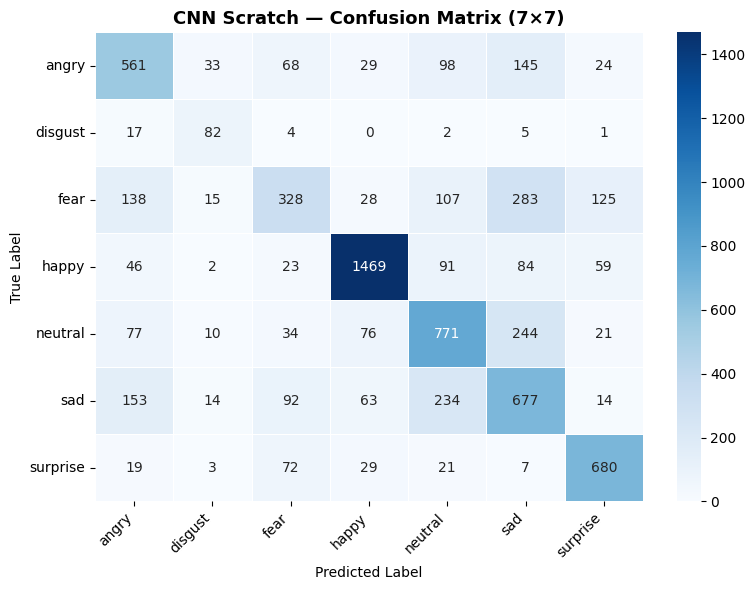


Model: MobileNet Frozen
              precision    recall  f1-score   support

       angry       0.37      0.50      0.43       958
     disgust       0.39      0.68      0.50       111
        fear       0.44      0.26      0.33      1024
       happy       0.73      0.62      0.67      1774
     neutral       0.45      0.52      0.48      1233
         sad       0.45      0.40      0.42      1247
    surprise       0.60      0.74      0.66       831

    accuracy                           0.51      7178
   macro avg       0.49      0.53      0.50      7178
weighted avg       0.52      0.51      0.51      7178



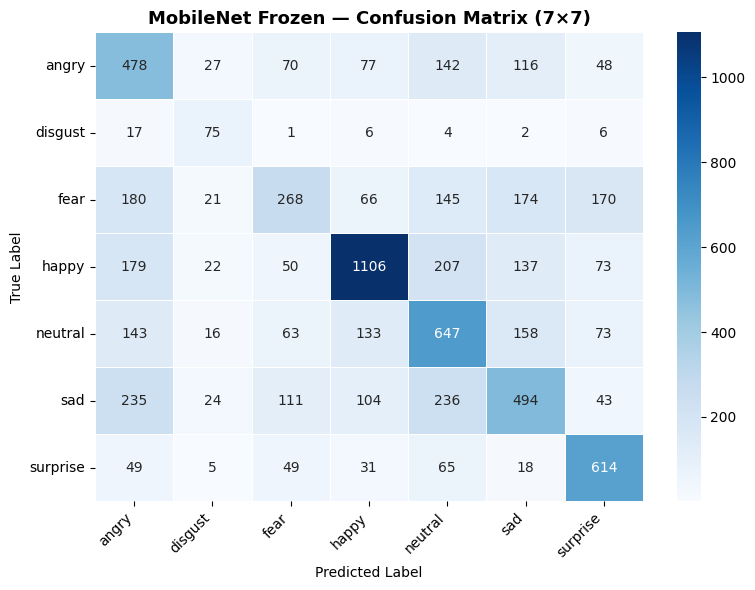


Model: MobileNet Finetune
              precision    recall  f1-score   support

       angry       0.44      0.45      0.45       958
     disgust       0.42      0.68      0.52       111
        fear       0.39      0.40      0.40      1024
       happy       0.74      0.74      0.74      1774
     neutral       0.50      0.51      0.50      1233
         sad       0.45      0.37      0.41      1247
    surprise       0.68      0.73      0.70       831

    accuracy                           0.55      7178
   macro avg       0.52      0.56      0.53      7178
weighted avg       0.55      0.55      0.55      7178



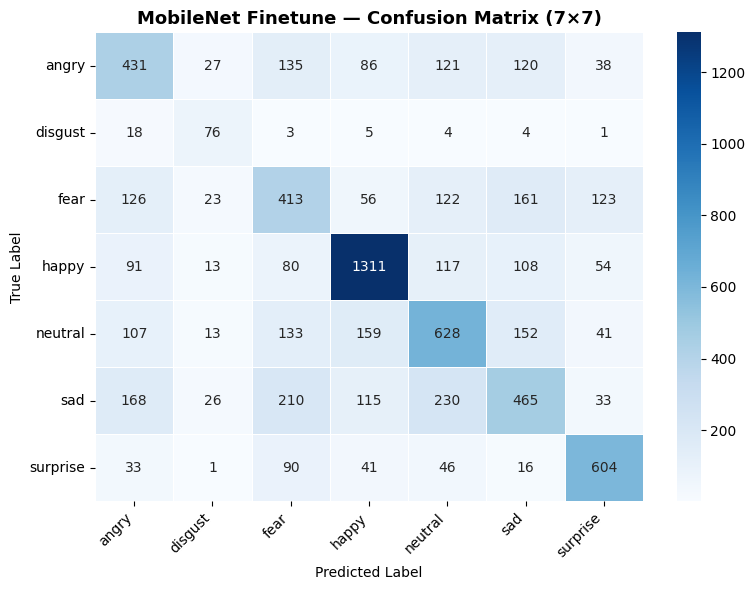


Model: VGG-Style
              precision    recall  f1-score   support

       angry       0.47      0.17      0.25       958
     disgust       0.25      0.68      0.37       111
        fear       0.28      0.07      0.12      1024
       happy       0.80      0.77      0.79      1774
     neutral       0.50      0.53      0.51      1233
         sad       0.38      0.62      0.47      1247
    surprise       0.58      0.83      0.68       831

    accuracy                           0.53      7178
   macro avg       0.47      0.53      0.46      7178
weighted avg       0.52      0.53      0.50      7178



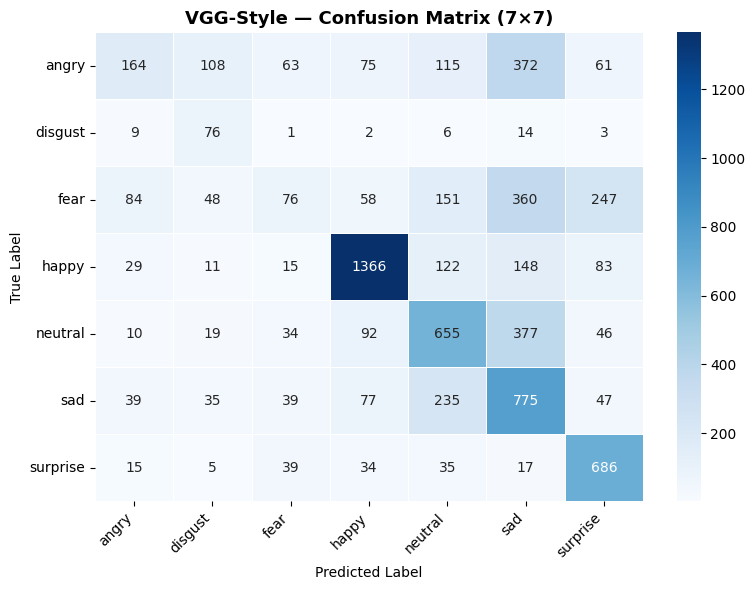

In [ ]:
def evaluate_model(model, val_ds, model_name):
    y_true, y_pred=[], []
    for batch_imgs, batch_labels in val_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=EMOTIONS))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix (7×7)', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = np.mean(y_true == y_pred)
    return acc, macro_f1
results = {}
results['CNN Scratch'] = evaluate_model(best_scratch,val_ds_gray,  'CNN Scratch')
results['MobileNet Frozen'] = evaluate_model(best_frozen,val_ds_color, 'MobileNet Frozen')
results['MobileNet Finetune'] = evaluate_model(best_finetune, val_ds_color, 'MobileNet Finetune')
results['VGG-Style'] = evaluate_model(best_vgg,val_ds_gray,  'VGG-Style')

In [ ]:
from sklearn.metrics import accuracy_score
import tensorflow as tf

IMG_SIZE_RGB = IMG_SIZE_COLOR

def evaluate_model(model, val_ds, gen_name, model_name):
    t0 = time.time()
    y_true_list, y_pred_list = [], []
    for batch_imgs, batch_labels in val_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(np.argmax(batch_labels.numpy(), axis=1))
    elapsed = time.time() - t0
    y_pred = np.array(y_pred_list)
    y_true = np.array(y_true_list)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    n_params = model.count_params()
    fps = len(y_true) / elapsed
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"Test Accuracy  : {acc*100:.2f}%")
    print(f"Macro F1       : {f1:.4f}")
    print(f"Parameters     : {n_params:,}")
    print(f"Inference FPS  : {fps:.1f}")
    print(f"Inference Time : {elapsed:.2f}s for {len(y_true)} images")
    return acc, f1, n_params, fps, y_pred, y_true

model_A = best_scratch
model_B = best_finetune
model_C = best_vgg

acc_A, f1_A, params_A, fps_A, pred_A, true_A = evaluate_model(model_A, val_ds_gray,  'gray', 'CNN Scratch')
acc_B, f1_B, params_B, fps_B, pred_B, true_B = evaluate_model(model_B, val_ds_color, 'rgb',  'MobileNetV2 Fine-Tuned')
acc_C, f1_C, params_C, fps_C, pred_C, true_C = evaluate_model(model_C, val_ds_gray,  'gray', 'VGG-Style')



Model: CNN Scratch
Test Accuracy  : 63.64%
Macro F1       : 0.6149
Parameters     : 1,243,111
Inference FPS  : 719.3
Inference Time : 9.98s for 7178 images

Model: MobileNetV2 Fine-Tuned
Test Accuracy  : 54.72%
Macro F1       : 0.5310
Parameters     : 3,046,983
Inference FPS  : 610.1
Inference Time : 11.77s for 7178 images

Model: VGG-Style
Test Accuracy  : 52.91%
Macro F1       : 0.4555
Parameters     : 487,399
Inference FPS  : 734.0
Inference Time : 9.78s for 7178 images


In [ ]:
print("\n" + "="*75)
print(f"{'Model':<28} {'Val Acc':>9} {'Macro F1':>10} {'Params':>12} {'FPS':>8}")
print("="*75)
rows = [
    ('CNN from Scratch (A)',         acc_A, f1_A, params_A, fps_A),
    ('MobileNetV2 Fine-Tuned (B)',   acc_B, f1_B, params_B, fps_B),
    ('VGG-Style (C)',                acc_C, f1_C, params_C, fps_C),
]
for name, acc, f1, p, fps in rows:
    print(f"{name:<28} {acc*100:>8.2f}% {f1:>10.4f} {p:>12,} {fps:>8.1f}")
print("="*75)
best_idx = np.argmax([acc_A, acc_B, acc_C])
best_names = ['CNN Scratch', 'MobileNetV2 Fine-Tuned', 'VGG-Style']
best_model = [model_A, model_B, model_C][best_idx]
best_preds = [pred_A, pred_B, pred_C][best_idx]
best_trues = [true_A, true_B, true_C][best_idx]
print(f"\nBest model: {best_names[best_idx]}")


Model                          Val Acc   Macro F1       Params      FPS
CNN from Scratch (A)            63.64%     0.6149    1,243,111    719.3
MobileNetV2 Fine-Tuned (B)      54.72%     0.5310    3,046,983    610.1
VGG-Style (C)                   52.91%     0.4555      487,399    734.0

Best model: CNN Scratch


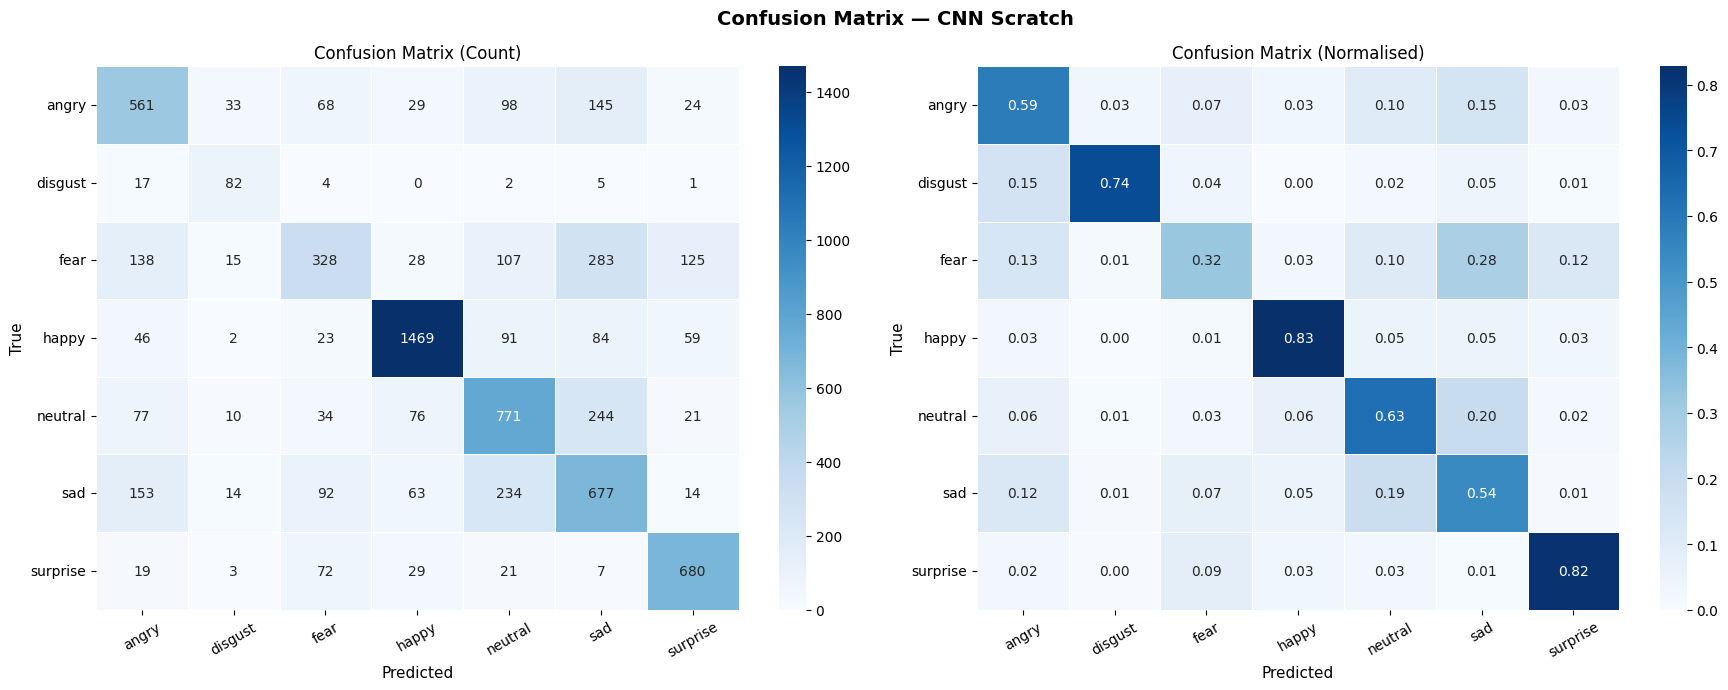

Saved: confusion_matrix.png


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, data, fmt, t in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Count', 'Normalised']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=classes, yticklabels=classes,
                    ax=ax, linewidths=0.5)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.set_title(f'Confusion Matrix ({t})', fontsize=12)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")
plot_confusion_matrix(
    best_trues, best_preds, EMOTIONS,
    f'Confusion Matrix — {best_names[best_idx]}',
    'confusion_matrix.png'
)

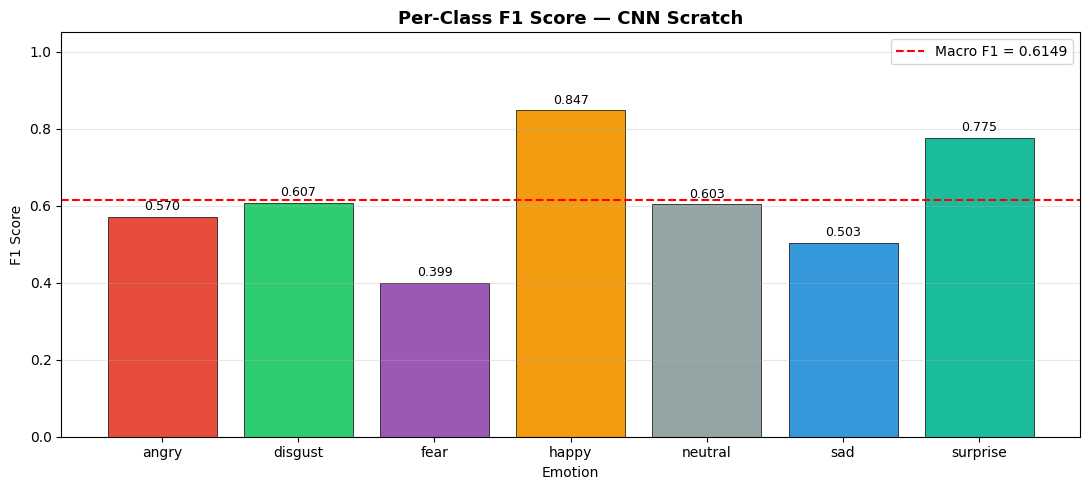

Saved: f1_per_class.png


In [ ]:
per_class_f1 = f1_score(best_trues, best_preds, average=None)
colors_f1 = ['#e74c3c','#2ecc71','#9b59b6','#f39c12','#95a5a6','#3498db','#1abc9c']
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(EMOTIONS, per_class_f1, color=colors_f1, edgecolor='black', linewidth=0.5)
ax.axhline(np.mean(per_class_f1), color='red', linestyle='--', linewidth=1.5,
           label=f'Macro F1 = {np.mean(per_class_f1):.4f}')
ax.set_title(f'Per-Class F1 Score — {best_names[best_idx]}', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion'); ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_per_class.png")

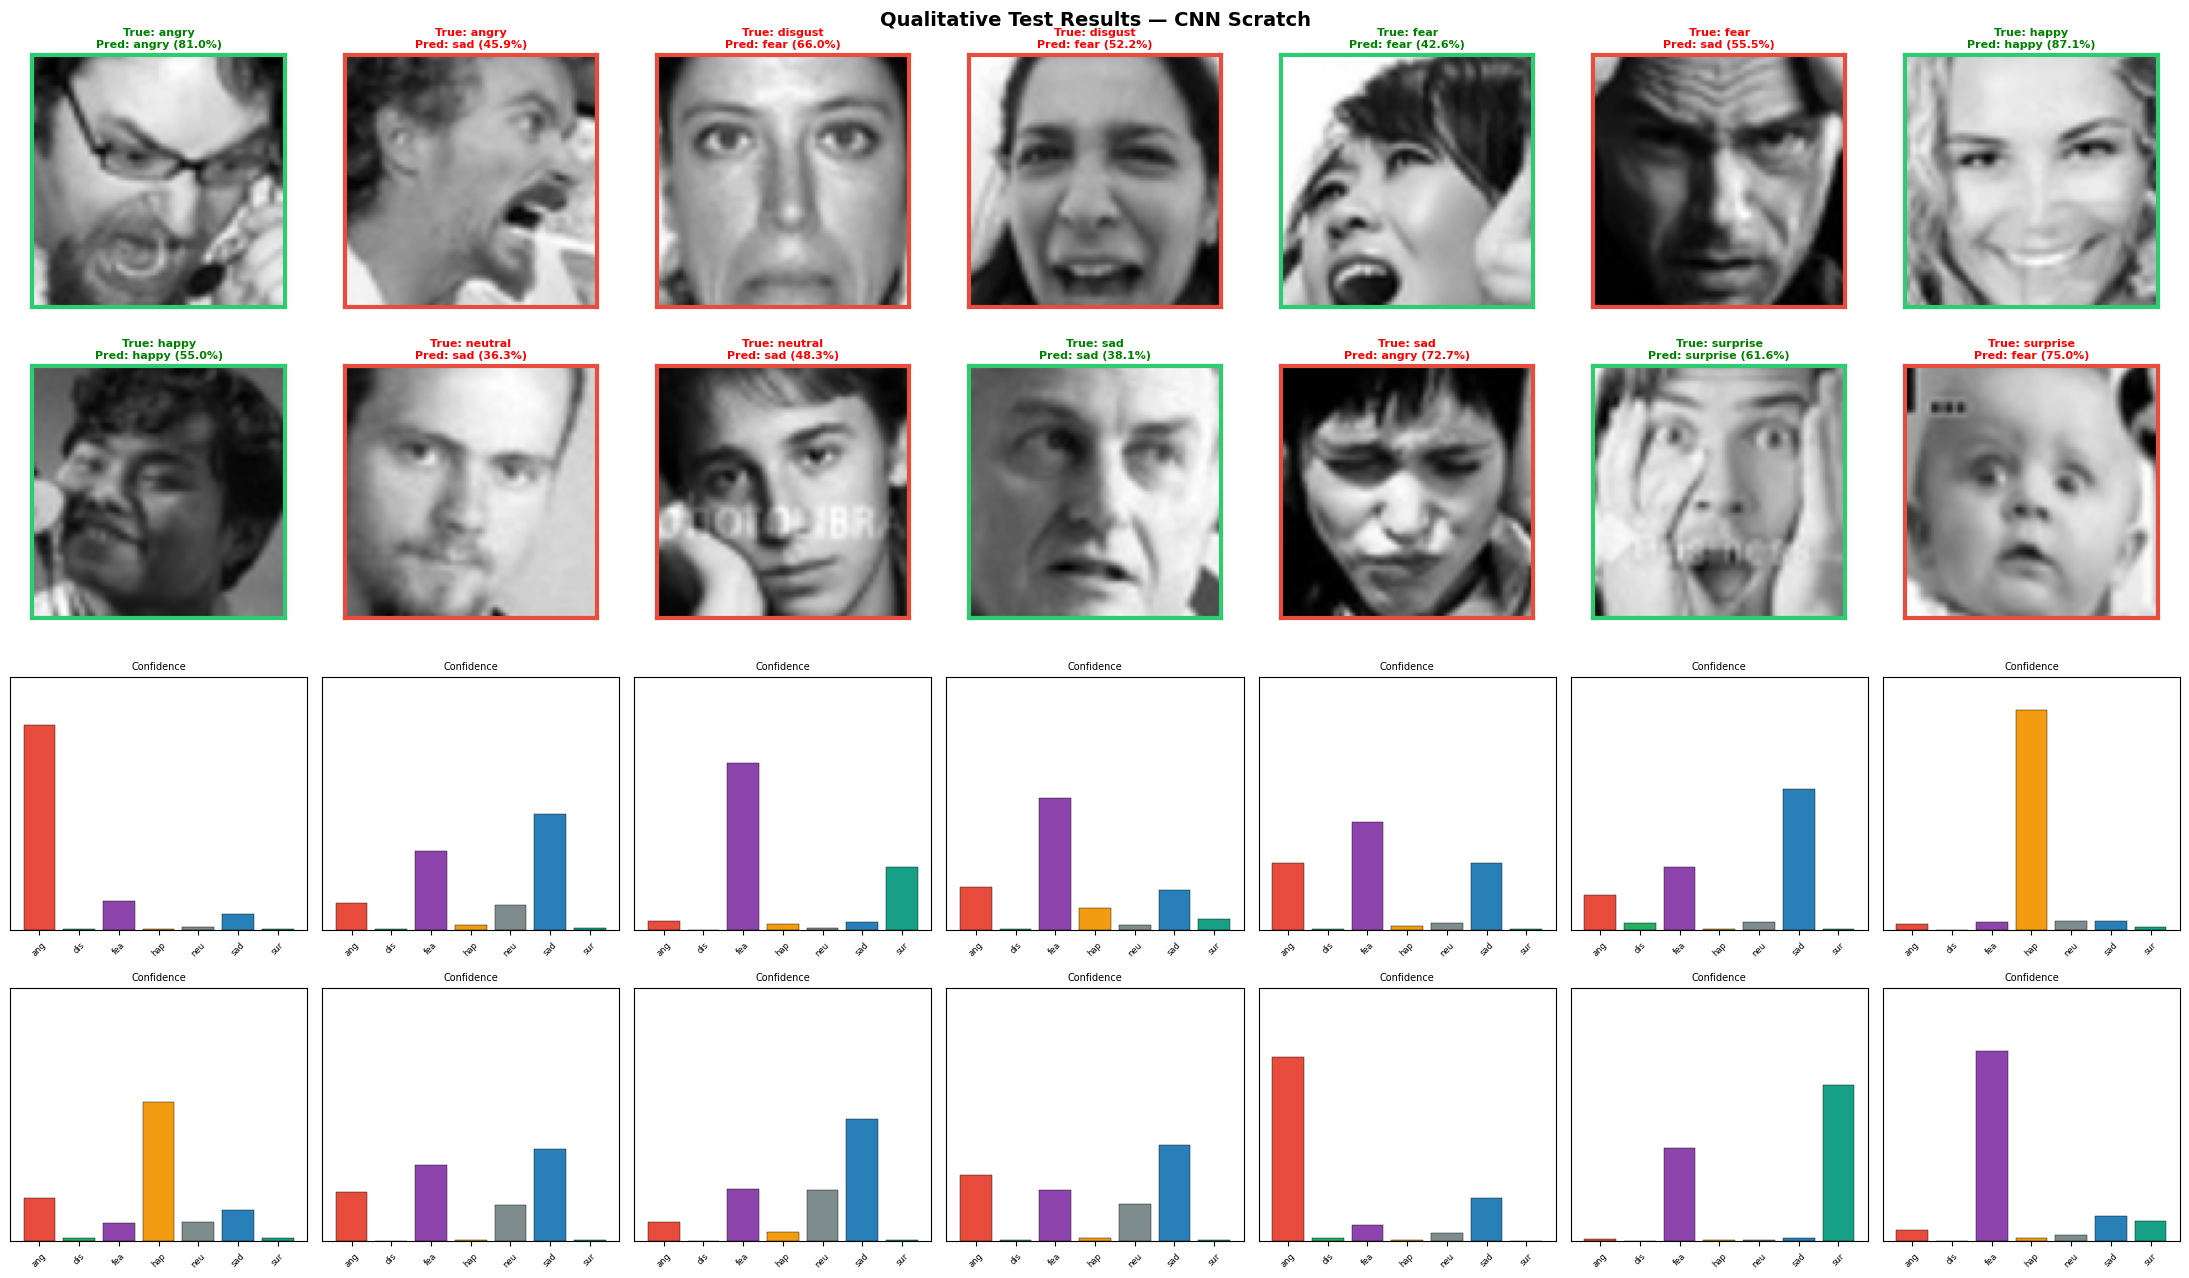

Saved: test_results_grid.png


In [ ]:
def predict_single(model, img_path, img_size, grayscale=True):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, 0, None
    if grayscale:
        face = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        face = cv2.GaussianBlur(face, (3, 3), 0)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        face = clahe.apply(face)
        face = cv2.resize(face, (img_size, img_size)).astype('float32') / 255.0
        face = face[np.newaxis, ..., np.newaxis]
    else:
        face = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        face = cv2.resize(face, (img_size, img_size)).astype('float32') / 255.0
        face = face[np.newaxis]
    preds = model(face, training=False).numpy()[0]
    idx = np.argmax(preds)
    return EMOTIONS[idx], float(preds[idx]), preds
test_samples = []
for cls in EMOTIONS:
    cls_dir = os.path.join(TEST_DIR, cls)
    imgs = sorted(os.listdir(cls_dir))[:2]
    for fname in imgs:
        test_samples.append((os.path.join(cls_dir, fname), cls))
use_gray  = (best_idx == 0)
use_size  = IMG_SIZE_GRAY if use_gray else IMG_SIZE_COLOR
fig, axes = plt.subplots(4, 7, figsize=(22, 13))
fig.suptitle(f'Qualitative Test Results — {best_names[best_idx]}', fontsize=14, fontweight='bold')
emotion_colors_plt = {
    'angry':'#e74c3c','disgust':'#27ae60','fear':'#8e44ad',
    'happy':'#f39c12','neutral':'#7f8c8d','sad':'#2980b9','surprise':'#16a085'
}
for ax_img, ax_bar, (path, true_cls) in zip(
    axes[:2].flatten(), axes[2:].flatten(), test_samples
):
    pred_emotion, conf, all_preds = predict_single(
        best_model, path, use_size, grayscale=use_gray
    )
    img_disp = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img_disp = cv2.resize(img_disp, (96, 96))
    correct = pred_emotion == true_cls
    border_color = '#2ecc71' if correct else '#e74c3c'
    ax_img.imshow(img_disp, cmap='gray')
    ax_img.set_title(
        f"True: {true_cls}\nPred: {pred_emotion} ({conf*100:.1f}%)",
        fontsize=8,
        color='green' if correct else 'red',
        fontweight='bold'
    )
    for spine in ax_img.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    ax_img.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    bar_colors = [emotion_colors_plt[e] for e in EMOTIONS]
    ax_bar.bar(range(NUM_CLASSES), all_preds, color=bar_colors, edgecolor='black', linewidth=0.3)
    ax_bar.set_xticks(range(NUM_CLASSES))
    ax_bar.set_xticklabels([e[:3] for e in EMOTIONS], fontsize=6, rotation=45)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_yticks([])
    ax_bar.set_title('Confidence', fontsize=7)
    ax_bar.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test_results_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: test_results_grid.png")

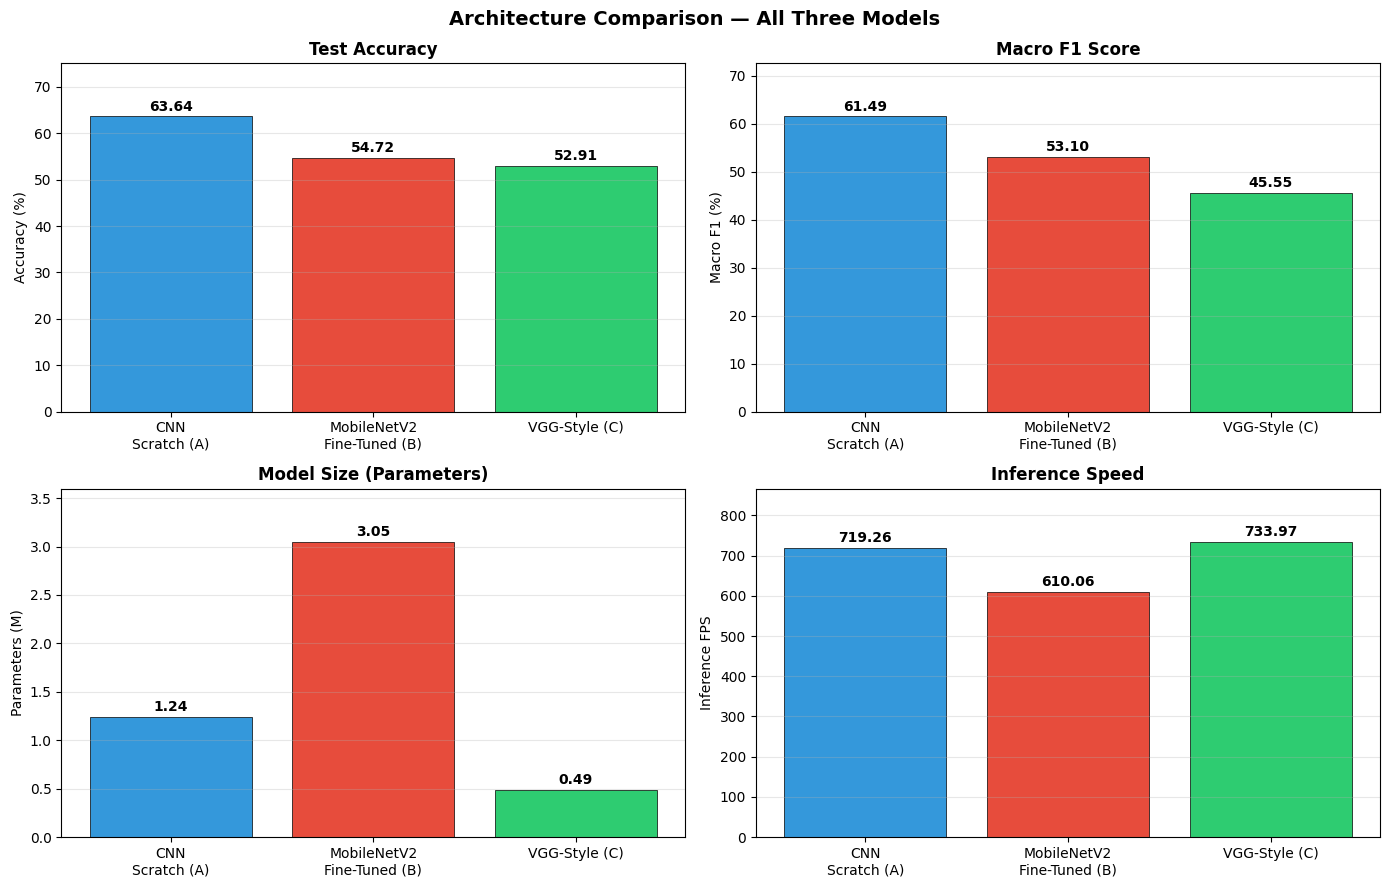

Saved: model_comparison.png


In [ ]:
model_names = ['CNN\nScratch (A)', 'MobileNetV2\nFine-Tuned (B)', 'VGG-Style (C)']
accs   = [acc_A*100,   acc_B*100,   acc_C*100]
f1s    = [f1_A*100,    f1_B*100,    f1_C*100]
params = [params_A/1e6, params_B/1e6, params_C/1e6]
fpss   = [fps_A,        fps_B,        fps_C]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Architecture Comparison — All Three Models', fontsize=14, fontweight='bold')
pal = ['#3498db', '#e74c3c', '#2ecc71']
for ax, data, ylabel, title in zip(
    axes.flatten(),
    [accs, f1s, params, fpss],
    ['Accuracy (%)', 'Macro F1 (%)', 'Parameters (M)', 'Inference FPS'],
    ['Test Accuracy', 'Macro F1 Score', 'Model Size (Parameters)', 'Inference Speed']
):
    bars = ax.bar(model_names, data, color=pal, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(data)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(data) * 1.18)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

In [ ]:
best_model.save('fixed_model.keras')
print(f"✓ Best model saved as 'fixed_model.keras'")
print(f"  Architecture : {best_names[best_idx]}")
print(f"  Test Accuracy: {max(acc_A, acc_B, acc_C)*100:.2f}%")
print(f"  Input shape  : {best_model.input_shape}")
from google.colab import files
files.download("fixed_model.keras")

✓ Best model saved as 'fixed_model.keras'
  Architecture : CNN Scratch
  Test Accuracy: 63.64%
  Input shape  : (None, 48, 48, 1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
param_counts = {
    'CNN Scratch': best_scratch.count_params(),
    'MobileNet Frozen': best_frozen.count_params(),
    'MobileNet Finetune': best_finetune.count_params(),
    'VGG-Style': best_vgg.count_params(),
}
train_times = {
    'CNN Scratch': time_scratch,
    'MobileNet Frozen': time_frozen,
    'MobileNet Finetune': time_finetune,
    'VGG-Style': time_vgg,
}
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Val Accuracy': [f'{v[0]*100:.2f}%' for v in results.values()],
    'Macro F1': [f'{v[1]:.4f}' for v in results.values()],
    'Parameters': [f'{param_counts[k]:,}' for k in results],
    'Train Time(s)': [f'{train_times[k]:.0f}s' for k in results],
})
print("\n" + "="*70)
print(" MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string(index=False))
best_model_name = max(results, key=lambda k: results[k][0])
print(f"\nBest model: {best_model_name} "
      f"(val accuracy = {results[best_model_name][0]*100:.2f}%)")


 MODEL COMPARISON TABLE
             Model Val Accuracy Macro F1 Parameters Train Time(s)
       CNN Scratch       63.64%   0.6149  1,243,111          488s
  MobileNet Frozen       51.30%   0.4984  3,046,983          419s
MobileNet Finetune       54.72%   0.5310  3,046,983          428s
         VGG-Style       52.91%   0.4555    487,399          275s

Best model: CNN Scratch (val accuracy = 63.64%)
